In [49]:
import numpy as np
import sklearn as sk
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


import matplotlib.pyplot as plt

from utils import gen_data, show_first_five

In [50]:
x, y = gen_data()

print(x.shape, y.shape)

print(x[:5], '\n', y[:5])

(100, 1) (100,)
[[-6.        ]
 [-5.87878788]
 [-5.75757576]
 [-5.63636364]
 [-5.51515152]] 
 [ 0.15476745 -0.0987637   0.0498698  -0.38759842  0.04263387]


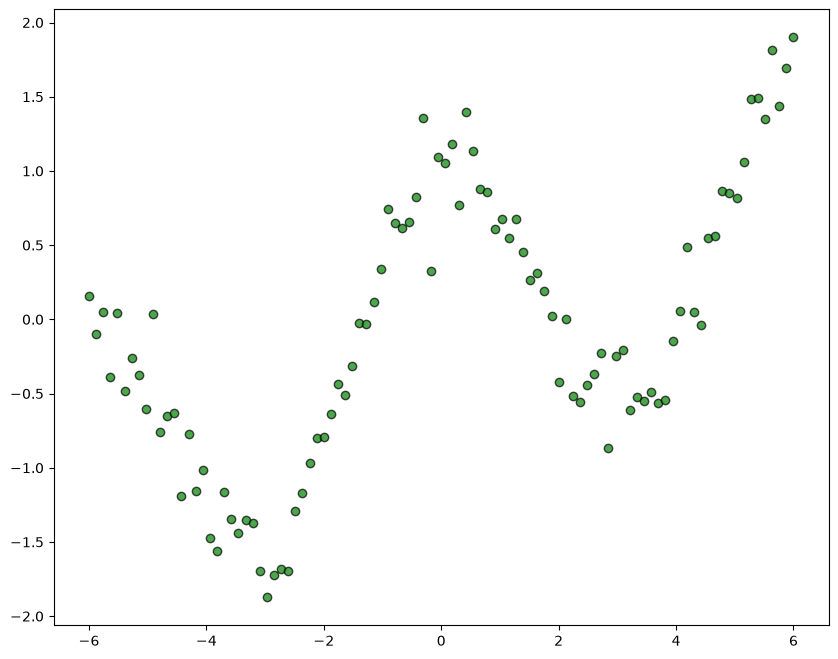

In [51]:
plt.figure(figsize=(10, 8))

plt.scatter(x, y, color='green', alpha=0.7, edgecolors='black')

## Spliting Data

In [52]:
x_train, _x, y_train, _y = train_test_split(x, y, test_size=0.6, random_state=True)
x_cv, x_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.5, random_state=True)

print(x_train.shape, x_cv.shape, x_test.shape)

(40, 1) (30, 1) (30, 1)


## Scaling Data

In [53]:
scaler = StandardScaler()

# Scaling Train Data
x_train_scaled = scaler.fit_transform(x_train)

# Scaling CV Data
x_cv_scaled = scaler.transform(x_cv)

# Scaling Test Data
x_test_scaled = scaler.transform(x_test)

arrays = [x_train_scaled, x_cv_scaled, x_test_scaled]

print(x_train_scaled.shape, x_cv_scaled.shape, x_test_scaled.shape)
show_first_five([x_train_scaled, x_cv_scaled, x_test_scaled])

(40, 1) (30, 1) (30, 1)
[[-0.41812555]
 [ 0.80565654]
 [ 0.94163233]
 [-0.01019818]
 [ 0.15977155]]
[[1.8594689 ]
 [0.43172313]
 [0.83965049]
 [1.55352337]
 [0.66968075]]
[[-0.28214976]
 [ 0.36373523]
 [-0.31614371]
 [-0.55410133]
 [ 0.02379576]]


## Making Data Polynomial

### And Checking Each Degrees Error to Choose the Best Polynomial Degree

In [54]:
#TODO: train all on cv and train and then check the lowest MSE on both.

model_mses_train = []
model_mses_cv = []

for i in range(10):
    
    poly = PolynomialFeatures(degree=i)

    # Making Train Data Polynomial
    x_train_scaled_mapped = poly.fit_transform(x_train_scaled)

    # Making CV Data Polynomial
    x_cv_scaled_mapped = poly.transform(x_cv_scaled)

    # Making Test Data Polynomial
    x_test_scaled_mapped = poly.transform(x_test_scaled)

    # ------------- Training Model ----------------------
    model = Ridge(alpha=0.01)
    model.fit(x_train_scaled_mapped, y_train)
    
    #? Predict Train
    yhat_train = model.predict(x_train_scaled_mapped)
    mse_train = mean_squared_error(y_train, yhat_train)
    
    #? Predict CV
    yhat_cv = model.predict(x_cv_scaled_mapped)
    mse_cv = mean_squared_error(y_cv, yhat_cv)

    #? Train Score
    # print(model.score(x_train_scaled_mapped, y_train))
    
    #? CV Scode
    # print(model.score(x_cv_scaled_mapped, y_cv))
    
    model_mses_train.append(mse_train)
    model_mses_cv.append(mse_cv)

print(model_mses_cv)



[0.659350856945491, 0.42275121091262663, 0.4774205438011449, 0.4986110472694577, 0.14088985862882641, 0.21193145546833517, 0.0356411746183206, 0.03208043514369046, 0.032706703732562806, 0.029258290737326723]


In [55]:
indice_min_cv = np.argmin(model_mses_cv)
indice_min_train = np.argmin(model_mses_train)

print(f'Model Min MSE on Training Set was: {model_mses_train[indice_min_train]}', '\n', f'With degree of {indice_min_train+1}')
print(f'Model Min MSE on Dev Set was: {model_mses_cv[indice_min_cv]}', '\n', f'With degree of {indice_min_cv+1}')


Model Min MSE on Training Set was: 0.04511921037850476 
 With degree of 10
Model Min MSE on Dev Set was: 0.029258290737326723 
 With degree of 10


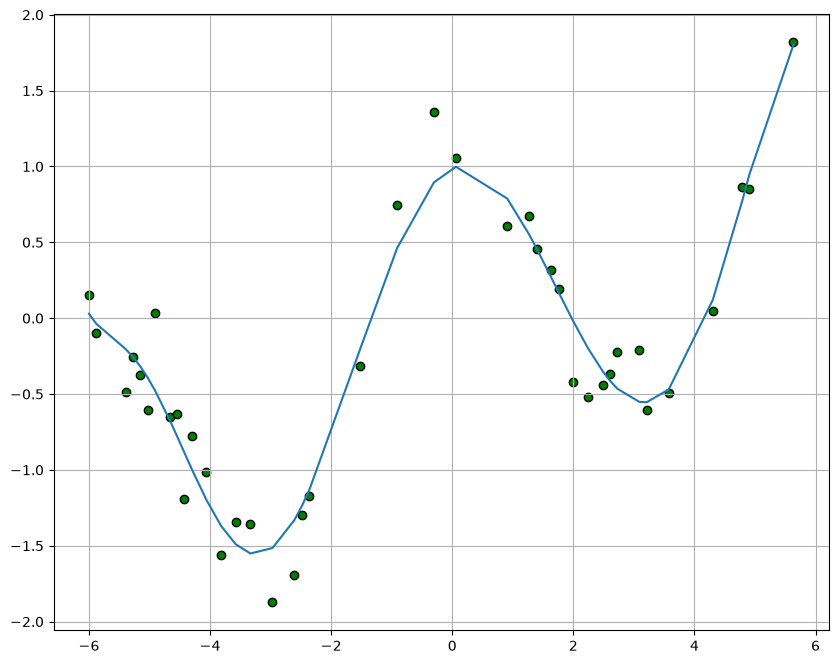

In [56]:
# ------------- Plotting Model ---------------------
plt.figure(figsize=(10,8))

idx = np.argsort(x_train[:, 0])

plt.scatter(x_train, y_train, edgecolors='black', color='green', label='Train')
plt.plot(x_train[idx], yhat_train[idx], label='model')

plt.grid(True)
plt.show()

In [57]:
# model = Ridge(alpha=0.01)
# model.fit(x_train_scaled_mapped, y_train)
# yhat_train = model.predict(x_train_scaled_mapped)

# print(model.score(x_train_scaled_mapped, y_train))

In [58]:
# plt.figure(figsize=(10,8))

# idx = np.argsort(x_train[:, 0])

# plt.scatter(x_train, y_train, edgecolors='black', color='green', label='Train')
# plt.plot(x_train[idx], yhat_train[idx], label='model')

# plt.grid(True)
# plt.show()